## Imports

In [40]:
import os
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

In [26]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, PrecisionRecallDisplay, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

## Load The Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("ylmzasel/scrna-seq-cancer-microenvironment-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'scrna-seq-cancer-microenvironment-classification' dataset.
Path to dataset files: /kaggle/input/scrna-seq-cancer-microenvironment-classification


In [3]:
print(os.listdir(path))

['Gene_Expression_Analysis_and_Disease_Relationship_Synthetic.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'Gene_Expression_Analysis_and_Disease_Relationship_Synthetic.csv'))

## Explore The Data


In [18]:
df.head()

,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1,Cell_Type_Cancer,Cell_Type_Fibroblast,Cell_Type_T_Cell
0,1,5.565866,4.546474,10.532535,2.113285,0.951138,9.580415,7.818137,0,0,1
1,1,5.351163,3.840752,10.642705,4.361618,0.952454,10.540695,8.298277,0,0,1
2,1,4.935363,2.271616,10.389736,2.839926,1.906194,8.416975,7.158779,0,0,1
3,1,4.095084,14.881377,3.268237,3.204284,9.922546,7.357785,0.016234,1,0,0
4,1,4.669715,5.444694,2.561298,14.046708,3.126553,3.372407,11.646391,0,1,0


In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,5.002702,7.319094,5.982890,6.852504,4.952360,7.043063,6.516869
std,0.495695,4.959009,4.383173,4.861748,3.692807,3.424917,3.970911
min,3.436678,1.087581,1.015551,1.176086,0.500000,1.000000,-0.799966
25%,4.658408,3.286695,2.525109,3.011726,2.004656,4.276713,1.990183
50%,4.979579,4.773690,3.517219,4.144346,3.143158,6.732012,7.010630
75%,5.326971,12.947793,11.269680,12.645769,9.255951,9.795390,10.563544
max,7.165827,21.508750,16.901272,19.199503,15.083534,17.994128,13.756952


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cell_ID               3000 non-null   object 
 1   Cell_Type             3000 non-null   object 
 2   Disease_Status        3000 non-null   object 
 3   Gene_E_Housekeeping   3000 non-null   float64
 4   Gene_A_Oncogene       3000 non-null   float64
 5   Gene_B_Immune         3000 non-null   float64
 6   Gene_C_Stromal        3000 non-null   float64
 7   Gene_D_Therapy        3000 non-null   float64
 8   Pathway_Score_Inflam  3000 non-null   float64
 9   UMAP_1                3000 non-null   float64
dtypes: float64(7), object(3)
memory usage: 234.5+ KB


In [10]:
df.shape

(3000, 10)

In [11]:
df['Disease_Status'].unique()

array(['Tumor', 'Healthy_Control'], dtype=object)

In [12]:
df['Cell_Type'].unique()


array(['T_Cell', 'Cancer', 'Fibroblast'], dtype=object)

## Preprocessing

In [13]:
df= df.drop(columns=['Cell_ID'])

In [14]:
cat = ['Cell_Type']

dummy = pd.get_dummies(df[cat],drop_first=False).astype(int)
df = pd.concat([df,dummy],axis=1)
df = df.drop(cat,axis=1)
df.head()

,Disease_Status,Gene_E_Housekeeping,Gene_A_Oncogene,Gene_B_Immune,Gene_C_Stromal,Gene_D_Therapy,Pathway_Score_Inflam,UMAP_1,Cell_Type_Cancer,Cell_Type_Fibroblast,Cell_Type_T_Cell
0,Tumor,5.565866,4.546474,10.532535,2.113285,0.951138,9.580415,7.818137,0,0,1
1,Tumor,5.351163,3.840752,10.642705,4.361618,0.952454,10.540695,8.298277,0,0,1
2,Tumor,4.935363,2.271616,10.389736,2.839926,1.906194,8.416975,7.158779,0,0,1
3,Tumor,4.095084,14.881377,3.268237,3.204284,9.922546,7.357785,0.016234,1,0,0
4,Tumor,4.669715,5.444694,2.561298,14.046708,3.126553,3.372407,11.646391,0,1,0


In [17]:
df['Disease_Status'] =  df['Disease_Status'].astype('category').cat.codes

### class imbalance problem

In [25]:
df['Disease_Status'].value_counts()

,count
Disease_Status,
1,2595
0,405


## Visualization

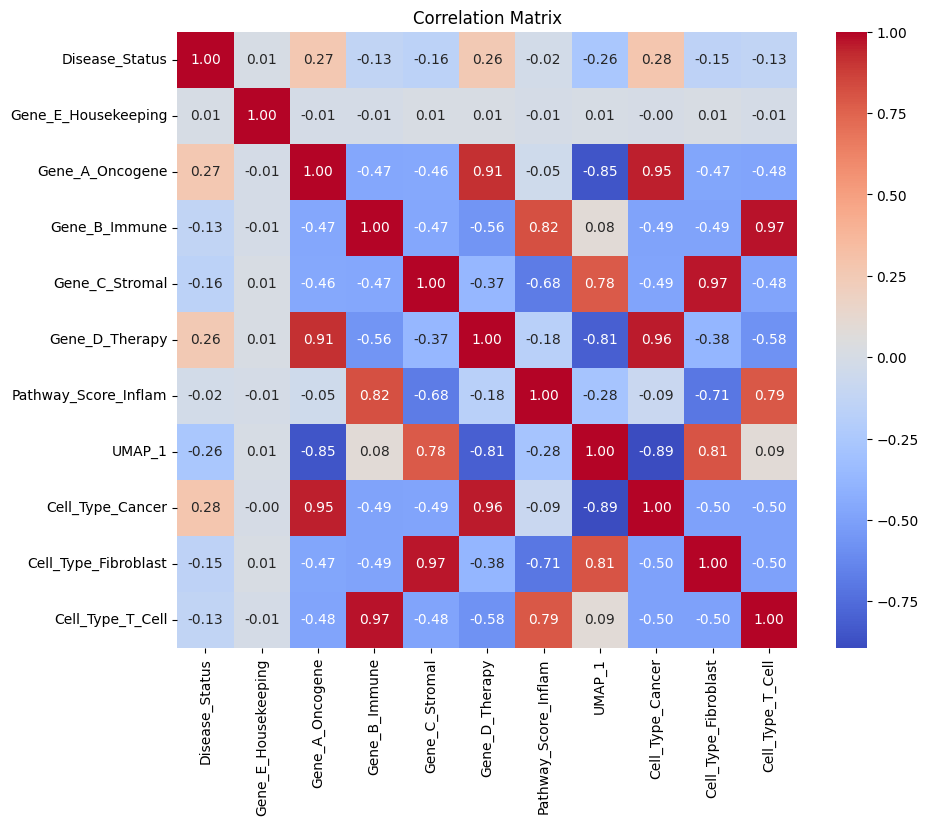

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation plot
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


### Gene_E_Housekeeping few high outliers

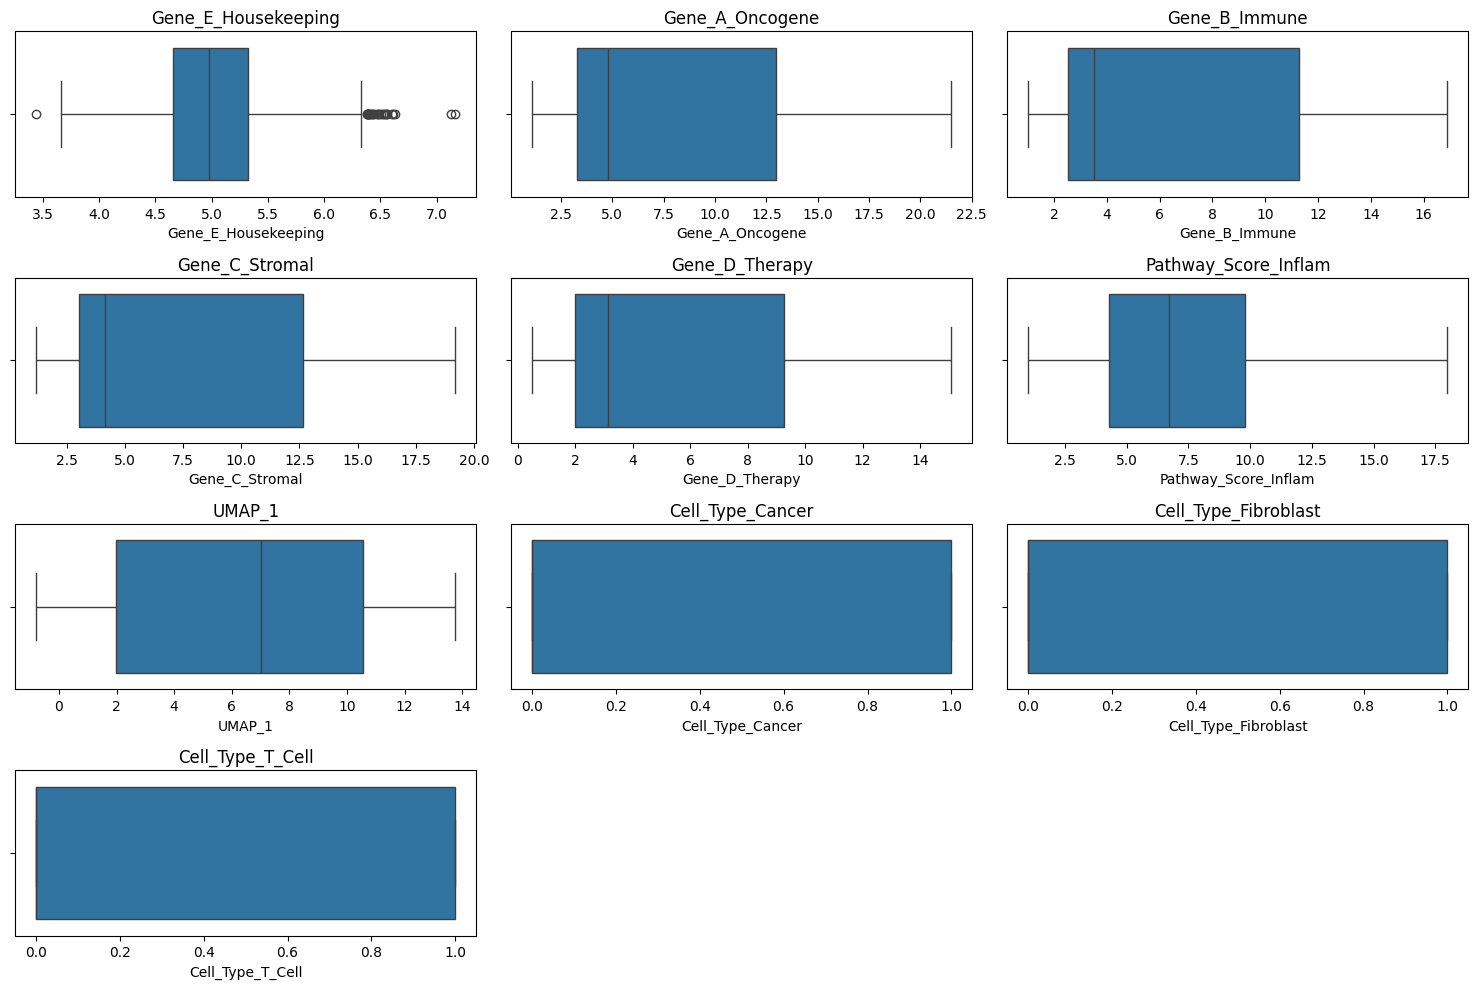

In [22]:
# Outlier plots (Box plots for numerical columns)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1) # Changed subplot layout to 4x3
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Model

In [19]:
X = df.drop('Disease_Status',axis=1)
y = df['Disease_Status']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [28]:
clf = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
)

In [30]:
pip = Pipeline(steps=[

                      ('scaler', StandardScaler()),
                      ('smote', SMOTE(random_state=42)),
                      ('clf', clf)
])

In [31]:
pip.fit(X_train,y_train)
y_pred= pip.predict(X_test)
y_score = pip.predict_proba(X_test)[:, 1]

## Results

In [32]:
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_score))
print("PR-AUC  :", average_precision_score(y_test, y_score))


              precision    recall  f1-score   support

           0     0.2269    0.3333    0.2700        81
           1     0.8877    0.8227    0.8540       519

    accuracy                         0.7567       600
   macro avg     0.5573    0.5780    0.5620       600
weighted avg     0.7985    0.7567    0.7752       600

Confusion matrix:
 [[ 27  54]
 [ 92 427]]
ROC-AUC : 0.7249458835842907
PR-AUC  : 0.9514680803591204


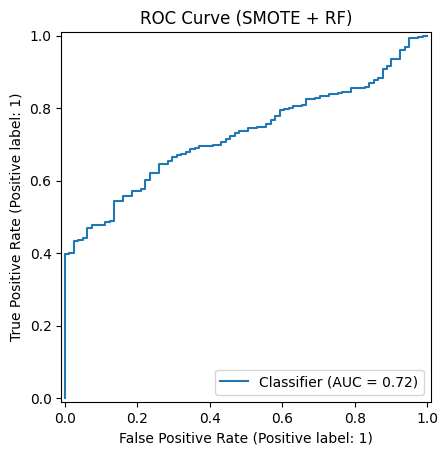

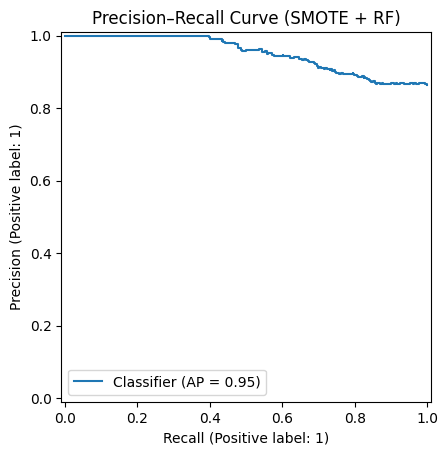

In [33]:
# curves
import matplotlib.pyplot as plt
RocCurveDisplay.from_predictions(y_test, y_score)
plt.title("ROC Curve (SMOTE + RF)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_score)
plt.title("Precision–Recall Curve (SMOTE + RF)")
plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(pip, param_grid, cv=3, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)


{'clf__max_depth': None, 'clf__min_samples_split': 10, 'clf__n_estimators': 500}


In [37]:
y_score = pip.predict_proba(X_test)[:,1]
threshold = 0.4
y_pred_new = (y_score > threshold).astype(int)


In [42]:
print(classification_report(y_test, y_pred_new, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_new))
print("ROC-AUC :", roc_auc_score(y_test, y_score))
print("PR-AUC  :", average_precision_score(y_test, y_score))

              precision    recall  f1-score   support

           0     0.1538    0.1235    0.1370        81
           1     0.8673    0.8940    0.8805       519

    accuracy                         0.7900       600
   macro avg     0.5106    0.5087    0.5087       600
weighted avg     0.7710    0.7900    0.7801       600

Confusion matrix:
 [[ 10  71]
 [ 55 464]]
ROC-AUC : 0.7249458835842907
PR-AUC  : 0.9514680803591204


## feature-importance

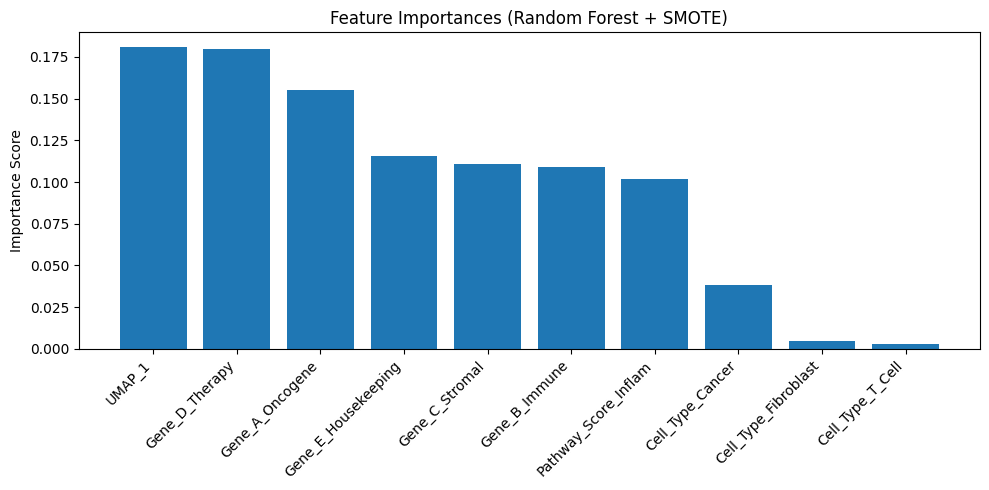

In [41]:
model = pip.named_steps["clf"]
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

features = X.columns  # since you said all numeric

# Sort importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(features)[indices], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.title("Feature Importances (Random Forest + SMOTE)")
plt.tight_layout()
plt.show()

## Neural Networks

In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [44]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", np.bincount(y_train_res))

After SMOTE: [2076 2076]


In [47]:
model = models.Sequential([
    layers.Input(shape=(X_train_res.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [48]:
history = model.fit(
    X_train_res, y_train_res,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate
y_score = model.predict(X_test_scaled).ravel()
y_pred = (y_score > 0.5).astype(int)


Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6114 - loss: 0.6360 - val_accuracy: 0.5463 - val_loss: 0.6975
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6167 - loss: 0.5505 - val_accuracy: 0.6727 - val_loss: 0.6854
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6403 - loss: 0.5367 - val_accuracy: 0.7786 - val_loss: 0.6707
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6219 - loss: 0.5372 - val_accuracy: 0.8111 - val_loss: 0.6605
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6225 - loss: 0.5409 - val_accuracy: 0.6402 - val_loss: 0.6870
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6347 - loss: 0.5204 - val_accuracy: 0.7966 - val_loss: 0.6532
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6347 - loss: 0.5198 - val_accuracy: 0.6486 - val_loss: 0.6784
Epoch 8/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6467 - loss: 0.5267 - val_accuracy: 0.5897 - val_loss

## Results

In [49]:
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_score))
print("PR-AUC  :", average_precision_score(y_test, y_score))

              precision    recall  f1-score   support

           0     0.2147    0.4321    0.2869        81
           1     0.8947    0.7534    0.8180       519

    accuracy                         0.7100       600
   macro avg     0.5547    0.5927    0.5524       600
weighted avg     0.8029    0.7100    0.7463       600

Confusion matrix:
 [[ 35  46]
 [128 391]]
ROC-AUC : 0.7190703870215752
PR-AUC  : 0.9487446645519295
